# **Symptom-Based Patient Triage System to Improve Healthcare Access using Machine Learning**

# 1. Import Libraries to be needed and import dataset from the google drive

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score)
import time

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After mounting, you can access your Google Drive files. For example, to load a CSV file, you would use pandas:

In [4]:
def import_dataset(url_path: str):
  file_path = f'/content/drive/MyDrive/TriageDataset/{url_path}'
  df_dataset_one = pd.read_csv(file_path, index_col=False)
  return df_dataset_one

In [5]:
df_dataset_one = import_dataset("Disease_symptom_and_patient_profile_dataset1.csv");
df_dataset_one.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [6]:
df_dataset_two = import_dataset("dataset2.csv");
df_dataset_two.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Melt all symptom columns into one long column
symptom_cols = [c for c in df_dataset_two.columns if c.startswith('Symptom_')]
df_dataset_two_melted = df_dataset_two.melt(id_vars=['Disease'], value_vars=symptom_cols, value_name='symptom')

df_dataset_two_melted = df_dataset_two_melted.dropna(subset=['symptom'])
df_dataset_two_melted

#turn all to symptom to lower cases and remove spaces
df_dataset_two_melted['symptom'] = df_dataset_two_melted['symptom'].str.strip().str.lower()
df_dataset_two_melted

df_dataset_two_melted['value'] = 1
df_dataset_two_melted

,Disease,variable,symptom,value
0,Fungal infection,Symptom_1,itching,1
1,Fungal infection,Symptom_1,skin_rash,1
2,Fungal infection,Symptom_1,itching,1
3,Fungal infection,Symptom_1,itching,1
4,Fungal infection,Symptom_1,itching,1
...,...,...,...,...
83461,Common Cold,Symptom_17,muscle_pain,1
83502,Common Cold,Symptom_17,muscle_pain,1
83543,Common Cold,Symptom_17,muscle_pain,1
83584,Common Cold,Symptom_17,muscle_pain,1


In [8]:
# Pivot back to binary columns
df_dataset_two_binary = df_dataset_two_melted.pivot_table(index=['Disease'], columns='symptom', values='value', aggfunc='max', fill_value=0).reset_index()
df_dataset_two_binary

symptom,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,(vertigo) Paroymsal Positional Vertigo,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,AIDS,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Acne,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,Alcoholic hepatitis,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,Allergy,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,Arthritis,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Bronchial Asthma,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,Cervical spondylosis,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
8,Chicken pox,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,Chronic cholestasis,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1


In [9]:
#decribe the datasets
df_dataset_two_binary.describe()

symptom,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,...,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,0.219512,0.048780,0.048780,0.024390,0.024390,0.024390,0.048780,0.024390,0.024390,0.024390,...,0.414634,0.024390,0.024390,0.024390,0.024390,0.097561,0.024390,0.024390,0.170732,0.195122
std,0.419058,0.218085,0.218085,0.156174,0.156174,0.156174,0.218085,0.156174,0.156174,0.156174,...,0.498779,0.156174,0.156174,0.156174,0.156174,0.300406,0.156174,0.156174,0.380949,0.401218
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# Standardise binary Yes/No → 1/0
symptom_cols_dataset_one = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']
df_dataset_one[symptom_cols_dataset_one] = df_dataset_one[symptom_cols_dataset_one].apply(lambda col: col.map({'Yes': 1, 'No': 0}))
df_dataset_one.head()


,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1,0,1,1,19,Female,Low,Normal,Positive
1,Common Cold,0,1,1,0,25,Female,Normal,Normal,Negative
2,Eczema,0,1,1,0,25,Female,Normal,Normal,Negative
3,Asthma,1,1,0,1,25,Male,Normal,Normal,Positive
4,Asthma,1,1,0,1,25,Male,Normal,Normal,Positive


In [11]:
df_dataset_one.rename(columns={
    'Fever': 'fever',
    'Cough': 'cough',
    'Fatigue': 'fatigue',
    'Difficulty Breathing': 'difficulty_breathing'
}, inplace=True)

# df_dataset_one.head()

# # Encode categorical demographics
df_dataset_one['Gender'] = df_dataset_one['Gender'].map({'Male': 1, 'Female': 0})
df_dataset_one['Blood Pressure'] = df_dataset_one['Blood Pressure'].map({'Low': 0, 'Normal': 1, 'High': 2})
df_dataset_one['Cholesterol Level'] = df_dataset_one['Cholesterol Level'].map({'Normal': 0, 'High': 1})
df_dataset_one.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1,0,1,1,19,0,0,0.0,Positive
1,Common Cold,0,1,1,0,25,0,1,0.0,Negative
2,Eczema,0,1,1,0,25,0,1,0.0,Negative
3,Asthma,1,1,0,1,25,1,1,0.0,Positive
4,Asthma,1,1,0,1,25,1,1,0.0,Positive


In [12]:
# Differentiating the dataseet
df_dataset_two_binary['data_source'] = 'dataset2'
df_dataset_one['data_source'] = 'dataset1'

df_dataset_two_binary.head()
df_dataset_one.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,data_source
0,Influenza,1,0,1,1,19,0,0,0.0,Positive,dataset1
1,Common Cold,0,1,1,0,25,0,1,0.0,Negative,dataset1
2,Eczema,0,1,1,0,25,0,1,0.0,Negative,dataset1
3,Asthma,1,1,0,1,25,1,1,0.0,Positive,dataset1
4,Asthma,1,1,0,1,25,1,1,0.0,Positive,dataset1


In [13]:
#combine both dataset
combined_data_frame = pd.concat([df_dataset_one, df_dataset_two_binary], axis=0, ignore_index=True)
combined_data_frame.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,Positive,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#fill in the missing value dataset with 0, since this are not present in the first dataset
# Fill missing symptom columns with 0 (symptom not present)
symptom_columns = [c for c in combined_data_frame.columns if c not in
                   ['Disease','Age','Gender','Blood Pressure','Cholesterol Level','Outcome Variable','source','index']]
combined_data_frame[symptom_columns] = combined_data_frame[symptom_columns].fillna(0)
combined_data_frame.head()


,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
#Same for dataset two, fill using imputted median/mean for fill our value for demography
combined_data_frame['Age'] = combined_data_frame['Age'].fillna(combined_data_frame['Age'].median())

#mode
combined_data_frame['Gender'] = combined_data_frame['Gender'].fillna(combined_data_frame['Gender'].mode()[0])

combined_data_frame['Blood Pressure'] = combined_data_frame['Blood Pressure'].fillna(combined_data_frame['Blood Pressure'].mode()[0])

combined_data_frame['Cholesterol Level'] = combined_data_frame['Cholesterol Level'].fillna(combined_data_frame['Cholesterol Level'].mode()[0])

combined_data_frame.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
non_symptom_cols = ['Disease', 'Age', 'Gender', 'Blood Pressure',
                    'Cholesterol Level', 'Outcome Variable',
                    'data_source', 'index', 'fever', 'cough',
                    'fatigue', 'difficulty_breathing']

symptom_columns = [c for c in combined_data_frame.columns
                   if c not in non_symptom_cols]

combined_data_frame[symptom_columns] = combined_data_frame[symptom_columns].fillna(0)

combined_data_frame.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#outcome variable is removed
combined_data_frame = combined_data_frame.drop(
    columns=['Outcome Variable'], errors='ignore'
)
combined_data_frame.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,data_source,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
file_path = '/content/drive/MyDrive/TriageDataset/urgency_reference.csv'
# df_dataset_one = pd.read_csv(file_path, index_col=False)

urgency_ref = pd.read_csv(file_path)

urgency_ref.head()

# Merge with combined dataset
combined_data_frame = combined_data_frame.merge(
    urgency_ref[['Disease', 'urgency_label']],
    on='Disease',
    how='left'
)

combined_data_frame

# # Check for any diseases that didn't get a label
# unmatched = combined_data_frame[combined_data_frame['urgency_label'].isna()]['Disease'].unique()
# print(f"Unmatched diseases: {unmatched}")

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,data_source,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,urgency_label
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GP Appointment
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Self Care
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Self Care
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Emergency
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Emergency
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,Tuberculosis,0.0,1,1,0.0,45.0,0.0,2.0,1.0,dataset2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,Emergency
400,Typhoid,0.0,0,1,0.0,45.0,0.0,2.0,1.0,dataset2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GP Appointment
401,Urinary tract infection,0.0,0,0,0.0,45.0,0.0,2.0,1.0,dataset2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GP Appointment
402,Varicose veins,0.0,0,1,0.0,45.0,0.0,2.0,1.0,dataset2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GP Appointment


In [19]:
def encode_urgency_label():
  # Encode target label
  label_encoder = LabelEncoder()
  combined_data_frame['urgency_encoded'] = label_encoder.fit_transform(combined_data_frame['urgency_label'])

  # Show the mapping so you know what each number means
  label_mapping = dict(zip(label_encoder.classes_,
                          label_encoder.transform(label_encoder.classes_)))
  return label_mapping;


In [20]:
#check missing value
def check_missing_value():
    print('Missing values per column:')
    missing = combined_data_frame.isnull().sum()
    print(missing[missing > 0])  # only show columns that have missing values
    print(f'\nTotal missing values: {combined_data_frame.isnull().sum().sum()}')
    print(f'Dataset shape: {combined_data_frame.shape}')
    unmatched = combined_data_frame[combined_data_frame['urgency_label'].isna()]['Disease'].unique()
    print('Unmatched disease:', unmatched)

In [21]:
encode_urgency_label()
check_missing_value()

Missing values per column:
urgency_label    1
dtype: int64

Total missing values: 1
Dataset shape: (404, 141)
Unmatched disease: ['Eating Disorders (Anorexia,...']


In [22]:
urgency_ref['Disease'] = urgency_ref['Disease'].replace(
    'Eating Disorders (Anorexia...',
    'Eating Disorders (Anorexia,...'  # match exactly what's in combined
)


In [23]:
unmatched = combined_data_frame[combined_data_frame['urgency_label'].isna()]['Disease'].unique()
print('Unmatched disease:', unmatched)

urgency_ref['Disease'] = urgency_ref['Disease'].str.strip()
combined_data_frame['Disease'] = combined_data_frame['Disease'].str.strip()

Unmatched disease: ['Eating Disorders (Anorexia,...']


In [24]:
# Check exact name in your combined dataset
print(combined_data_frame[combined_data_frame['Disease'].str.contains('Eating', na=False)]['Disease'].unique())

# Check exact name in your reference table
print(urgency_ref[urgency_ref['Disease'].str.contains('Eating', na=False)]['Disease'].unique())

urgency_ref['Disease'] = urgency_ref['Disease'].replace(
    'Eating Disorders (Anorexia...',
    'Eating Disorders (Anorexia,...'  # match exactly what's in combined
)

urgency_ref['Disease'] = urgency_ref['Disease'].str.strip()
combined_data_frame['Disease'] = combined_data_frame['Disease'].str.strip()

# Re-merge
combined_data_frame = combined_data_frame.drop(columns=['urgency_label'])
combined_data_frame = combined_data_frame.merge(
    urgency_ref[['Disease', 'urgency_label']],
    on='Disease',
    how='left'
)
print('Missing values remaining:', combined_data_frame['urgency_label'].isna().sum())


['Eating Disorders (Anorexia,...']
['Eating Disorders (Anorexia,...']
Missing values remaining: 0


In [25]:
combined_data_frame = combined_data_frame.drop(columns=['urgency_label'])
combined_data_frame = combined_data_frame.merge(
    urgency_ref[['Disease', 'urgency_label']],
    on='Disease',
    how='left'
)

combined_data_frame.head()

,Disease,fever,cough,fatigue,difficulty_breathing,Age,Gender,Blood Pressure,Cholesterol Level,data_source,...,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,urgency_encoded,urgency_label
0,Influenza,1.0,0,1,1.0,19.0,0.0,0.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,GP Appointment
1,Common Cold,0.0,1,1,0.0,25.0,0.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,Self Care
2,Eczema,0.0,1,1,0.0,25.0,0.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,Self Care
3,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Emergency
4,Asthma,1.0,1,0,1.0,25.0,1.0,1.0,0.0,dataset1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Emergency


In [26]:
check_missing_value()

Missing values per column:
Series([], dtype: int64)

Total missing values: 0
Dataset shape: (554, 141)
Unmatched disease: []


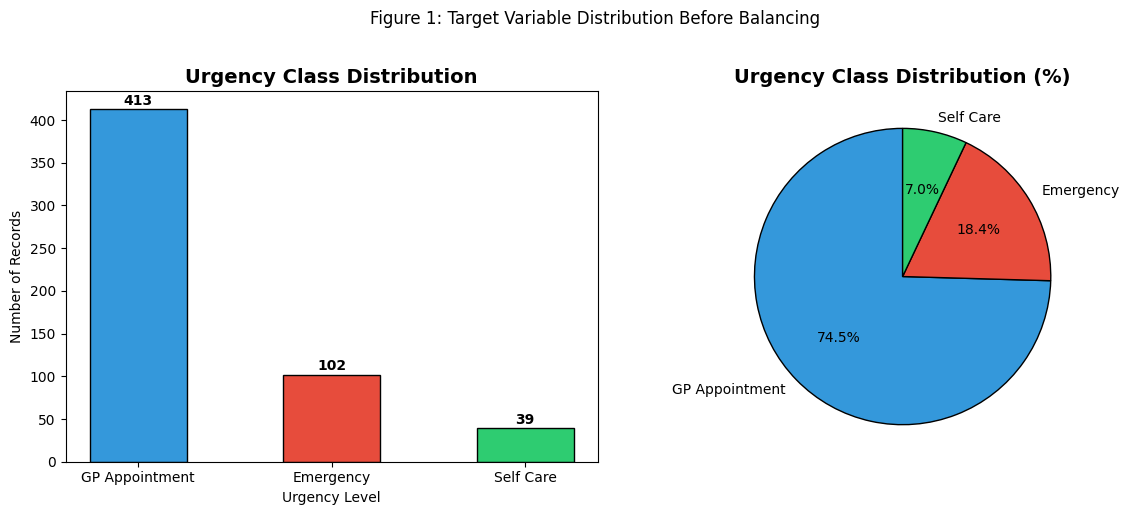

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts = combined_data_frame['urgency_label'].value_counts()
colors = {
    'Emergency':      '#e74c3c',
    'GP Appointment': '#3498db',
    'Self Care':      '#2ecc71'
}
bar_colors = [colors[label] for label in class_counts.index]

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_title('Urgency Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_xlabel('Urgency Level')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + 5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values,
            labels=class_counts.index,
            colors=bar_colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Urgency Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Figure 1: Target Variable Distribution Before Balancing',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print('Class Balance Check:')
print(combined_data_frame['urgency_label'].value_counts())
print()
print('Class Proportions:')
print(combined_data_frame['urgency_label'].value_counts(normalize=True).round(3) * 100)

Class Balance Check:
urgency_label
GP Appointment    413
Emergency         102
Self Care          39
Name: count, dtype: int64

Class Proportions:
urgency_label
GP Appointment    74.5
Emergency         18.4
Self Care          7.0
Name: proportion, dtype: float64


Urgency label mapping: {'Emergency': np.int64(0), 'GP Appointment': np.int64(1), 'Self Care': np.int64(2)}

Before SMOTE: (554, 137)
After SMOTE:  (1239, 137)
Class distribution after SMOTE: {'Emergency': np.int64(413), 'GP Appointment': np.int64(413), 'Self Care': np.int64(413)}


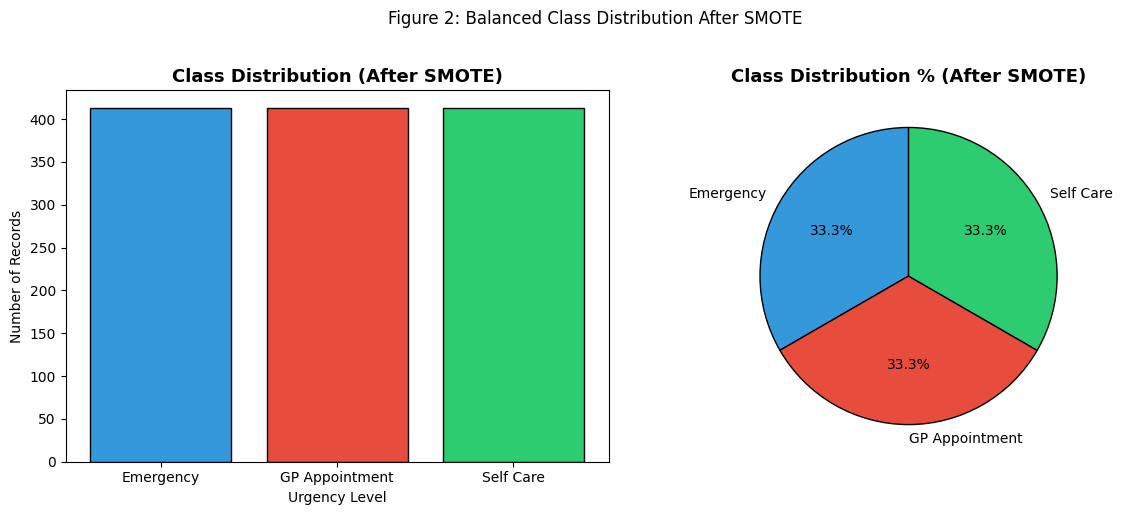

In [29]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# ── Encoder 1: urgency labels (keep this one for the model) ──
le = LabelEncoder()
combined_data_frame['urgency_encoded'] = le.fit_transform(
    combined_data_frame['urgency_label']
)
print('Urgency label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Encoder 2: data_source (separate encoder, never reuse le) ──
le_source = LabelEncoder()
combined_data_frame['data_source_encoded'] = le_source.fit_transform(
    combined_data_frame['data_source']
)

# ── Features and Target ──
drop_cols = ['Disease', 'urgency_label', 'urgency_encoded',
             'data_source', 'data_source_encoded', 'Outcome Variable']
feature_cols = [c for c in combined_data_frame.columns if c not in drop_cols]

X = combined_data_frame[feature_cols]
y = combined_data_frame['urgency_encoded']

# ── Apply SMOTE ──
smote = SMOTE(random_state=40)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f'\nBefore SMOTE: {X.shape}')
print(f'After SMOTE:  {X_resampled.shape}')

# ── Visualise After SMOTE ──
unique, counts = np.unique(y_resampled, return_counts=True)
labels = le.inverse_transform(unique)  # now works correctly

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
after_counts = dict(zip(labels, counts))
print('Class distribution after SMOTE:', after_counts)

bars = axes[0].bar(after_counts.keys(), after_counts.values(),
                   color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (After SMOTE)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_xlabel('Urgency Level')

axes[1].pie(after_counts.values(),
            labels=after_counts.keys(),
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Distribution % (After SMOTE)', fontsize=13, fontweight='bold')

plt.suptitle('Figure 2: Balanced Class Distribution After SMOTE', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Separate features (X) and target (y)
X = X_resampled
y = y_resampled
# X_resampled, y_resampled
# Split into train/test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures same class balance in both splits
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')

Training samples : 991
Testing samples  : 248
Number of features: 137


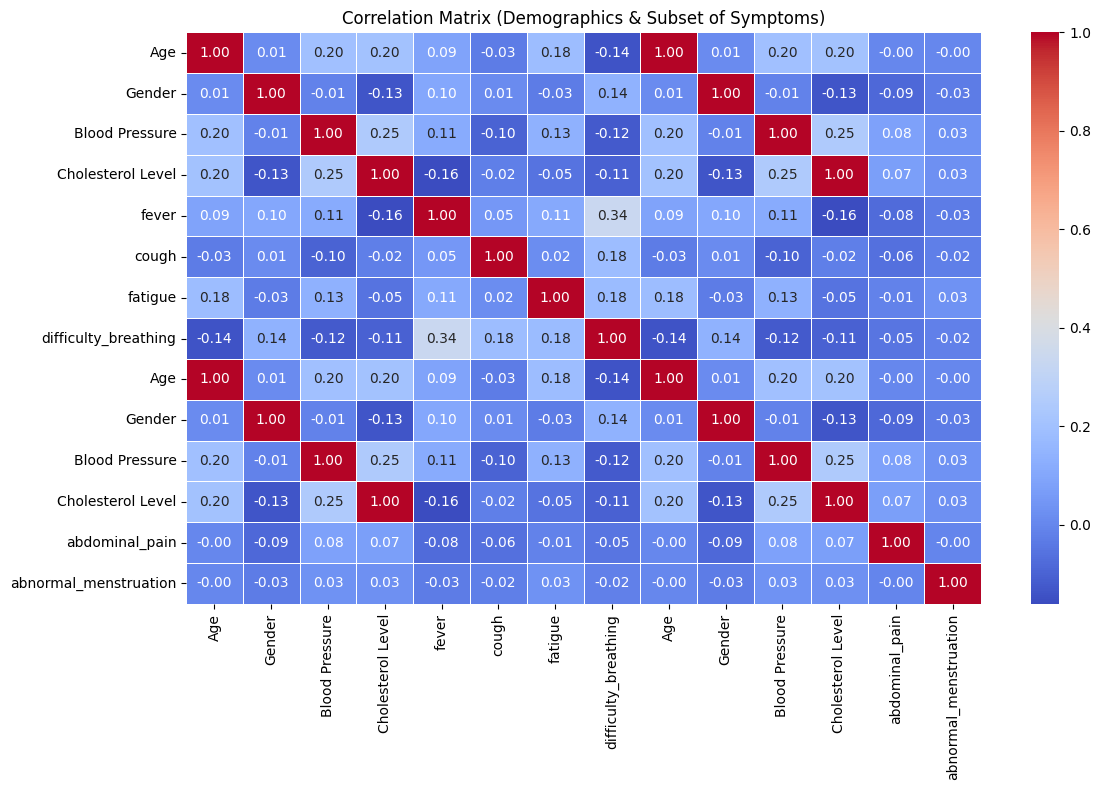

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting a subset of features for a readable heatmap
# Including demographics and the first 10 symptoms
selected_cols = ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level'] + list(X_train.columns[:10])
corr_matrix = X_train[selected_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Demographics & Subset of Symptoms)')
plt.tight_layout()
plt.show()

In [32]:
# Scale the features using StandardScaler (mean=0, std=1)
scaler = StandardScaler()

# Fit ONLY on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features scaled successfully!')

Features scaled successfully!


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
import time

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=20,
                                                  min_samples_split=5,
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, learning_rate=0.5,
                                         max_depth=6, eval_metric='mlogloss',
                                         random_state=42)
}

# Train each classifier and collect results
results = []

for name, clf in classifiers.items():
    start = time.time()

    # Train on SCALED data
    clf.fit(X_train_scaled, y_train)

    # Predict on SCALED test data
    y_pred = clf.predict(X_test_scaled)

    training_time = time.time() - start

    # Calculate metrics — macro for multiclass
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall    = recall_score(y_test, y_pred, average='macro')
    f1        = f1_score(y_test, y_pred, average='macro')

    results.append({
        'Model'            : name,
        'Accuracy'         : round(acc, 4),
        'Precision'        : round(precision, 4),
        'Recall'           : round(recall, 4),
        'F1 Score (Macro)' : round(f1, 4),
        'Training Time(s)' : round(training_time, 2)
    })

    print(f'{name:22s} -> Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Time: {training_time:.2f}s')

# Convert to DataFrame and sort by F1
results_df = pd.DataFrame(results).sort_values('F1 Score (Macro)', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print('\n')
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(results_df.to_string())

Logistic Regression    -> Accuracy: 0.7056 | Macro F1: 0.7048 | Time: 0.17s
Random Forest          -> Accuracy: 0.8831 | Macro F1: 0.8836 | Time: 1.58s
XGBoost                -> Accuracy: 0.8831 | Macro F1: 0.8836 | Time: 6.01s


MODEL COMPARISON SUMMARY
                 Model  Accuracy  Precision  Recall  F1 Score (Macro)  Training Time(s)
1        Random Forest    0.8831     0.8875  0.8832            0.8836              1.58
2              XGBoost    0.8831     0.8878  0.8833            0.8836              6.01
3  Logistic Regression    0.7056     0.7135  0.7052            0.7048              0.17


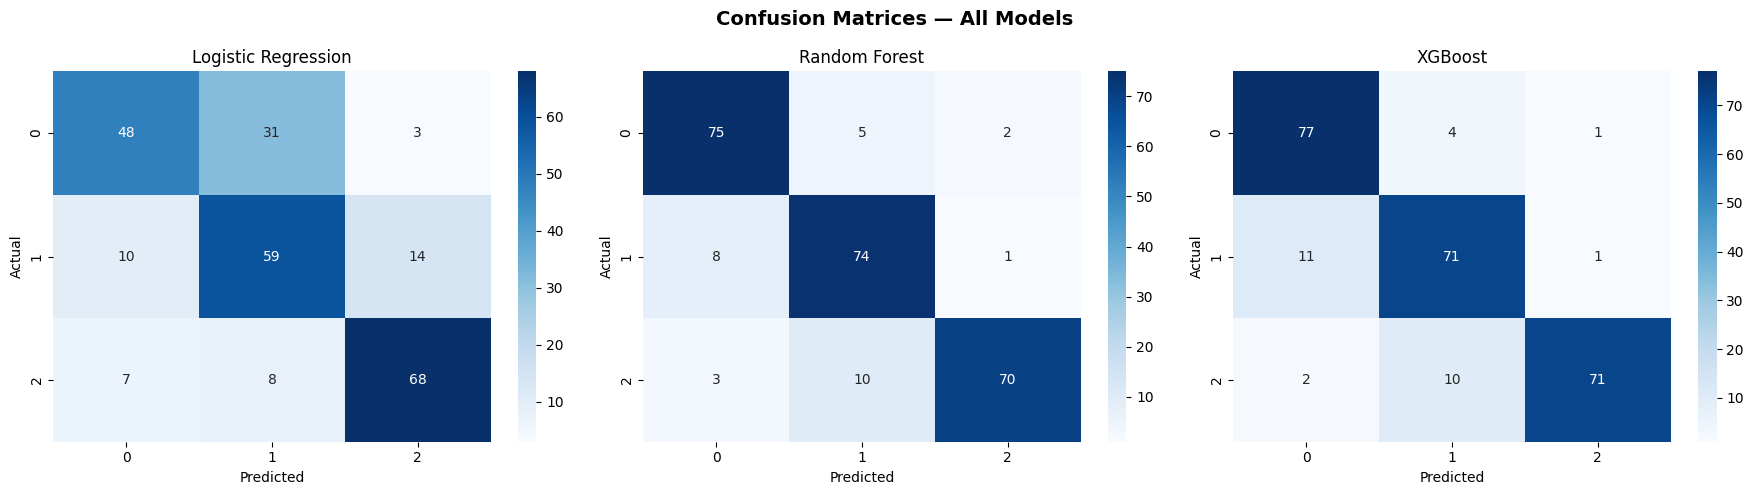

In [42]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_eval = [
    ('Logistic Regression', classifiers['Logistic Regression']),
    ('Random Forest',       classifiers['Random Forest']),
    ('XGBoost',             classifiers['XGBoost'])
]

for ax, (name, model) in zip(axes, models_eval):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()),
                ax=ax)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Adjusted Confusion Matrix:
                precision    recall  f1-score   support

     Emergency       0.72      0.96      0.82        82
GP Appointment       0.83      0.72      0.77        83
     Self Care       0.98      0.78      0.87        83

      accuracy                           0.82       248
     macro avg       0.85      0.82      0.82       248
  weighted avg       0.85      0.82      0.82       248



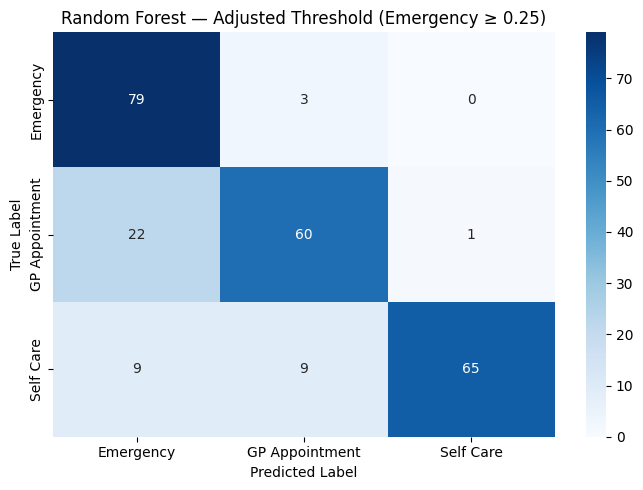

In [45]:
# Get probabilities instead of direct predictions
rf_model = classifiers['Random Forest']
y_prob = rf_model.predict_proba(X_test_scaled)

# Lower the Emergency threshold from default 0.5 to 0.3
# If Emergency probability > 0.3, classify as Emergency
emergency_idx = 0  # confirm with: print(le.classes_)

y_pred_adjusted = []
for probs in y_prob:
    if probs[emergency_idx] >= 0.25:  # lower threshold for Emergency
        y_pred_adjusted.append(emergency_idx)
    else:
        y_pred_adjusted.append(np.argmax(probs))

y_pred_adjusted = np.array(y_pred_adjusted)

# Check new confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_adjusted)
class_names = le.classes_

print("Adjusted Confusion Matrix:")
print(classification_report(y_test, y_pred_adjusted, target_names=class_names))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Random Forest — Adjusted Threshold (Emergency ≥ 0.25)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Adjusted Confusion Matrix:
                precision    recall  f1-score   support

     Emergency       0.80      0.95      0.87        82
GP Appointment       0.82      0.78      0.80        83
     Self Care       0.99      0.84      0.91        83

      accuracy                           0.86       248
     macro avg       0.87      0.86      0.86       248
  weighted avg       0.87      0.86      0.86       248



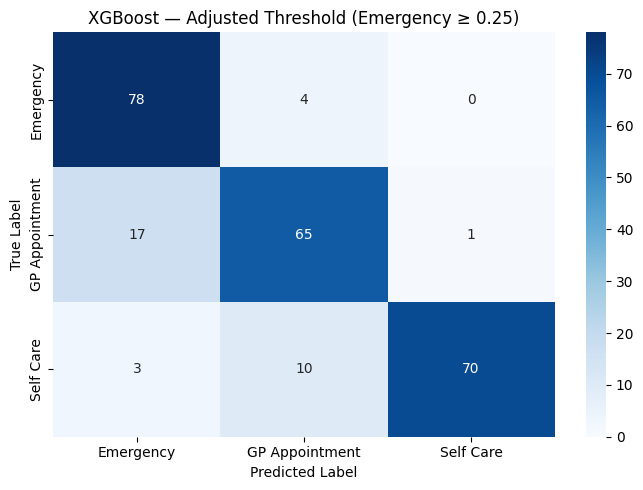

In [36]:
# Get probabilities instead of direct predictions
rf_model_two = classifiers['XGBoost']
y_prob = rf_model_two.predict_proba(X_test_scaled)

# Lower the Emergency threshold from default 0.5 to 0.3
# If Emergency probability > 0.3, classify as Emergency
emergency_idx = 0  # confirm with: print(le.classes_)

y_pred_adjusted = []
for probs in y_prob:
    if probs[emergency_idx] >= 0.15:  # lower threshold for Emergency
        y_pred_adjusted.append(emergency_idx)
    else:
        y_pred_adjusted.append(np.argmax(probs))

y_pred_adjusted = np.array(y_pred_adjusted)

# Check new confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_adjusted)
class_names = le.classes_

print("Adjusted Confusion Matrix:")
print(classification_report(y_test, y_pred_adjusted, target_names=class_names))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('XGBoost — Adjusted Threshold (Emergency ≥ 0.25)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Optimized Pipeline
enhanced_rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier',classifiers['Random Forest'])
])

# Train using existing variables X_train and y_train
enhanced_rf_pipe.fit(X_train, y_train)

# Evaluation
y_pred_enhanced = enhanced_rf_pipe.predict(X_test)

print("Enhanced Model Training Complete (Extreme Safety Weights).")
print(classification_report(y_test, y_pred_enhanced, target_names=['Emergency', 'GP Appointment', 'Self Care']))

Enhanced Model Training Complete (Extreme Safety Weights).
                precision    recall  f1-score   support

     Emergency       0.88      0.91      0.90        82
GP Appointment       0.84      0.89      0.87        83
     Self Care       0.96      0.87      0.91        83

      accuracy                           0.89       248
     macro avg       0.89      0.89      0.89       248
  weighted avg       0.89      0.89      0.89       248



In [38]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Re-initialize and fit LabelEncoder to ensure 'le' is defined before saving
# This step ensures 'le' is available in case of kernel restarts or out-of-order execution
le = LabelEncoder()
# Fit le on the 'urgency_label' column, which should be clean and available
le.fit(combined_data_frame['urgency_label'])

# Save the pipeline (using the consistent filename) and the label encoder mapping
joblib.dump(enhanced_rf_pipe, 'triage_model_with_smote_pipeline.joblib') # Changed filename for consistency
joblib.dump(le, 'label_encoder.joblib')
print('Model and encoder saved!')

Model and encoder saved!


In [39]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# ── Page Configuration ──
st.set_page_config(
    page_title='Patient Triage System',
    page_icon='🏥',
    layout="wide"
)

# ── Load Model and Encoder ──
@st.cache_resource
def load_model():
    model = joblib.load('triage_model_with_smote_pipeline.joblib')
    le    = joblib.load('label_encoder.joblib')
    return model, le

model, le = load_model()

# ── Get Feature Columns ──
@st.cache_resource
def get_feature_cols():
    demographic_cols = ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level']
    all_features     = list(model.named_steps['scaler'].feature_names_in_)
    symptom_cols     = [f for f in all_features if f not in demographic_cols]
    return all_features, symptom_cols

all_features, symptom_cols = get_feature_cols()

# ── Header ──
st.markdown("""
    <div style='text-align:center; padding: 1.5rem 0 0.5rem 0;'>
        <h1 style='font-size:2rem; margin-bottom:0.3rem;'>🏥 Patient Triage System</h1>
        <p style='color:gray; font-size:0.95rem;'>
            Answer the questions below to receive a triage recommendation
        </p>
    </div>
""", unsafe_allow_html=True)

# ── STEP 1: About You ──
# User Inputs
st.sidebar.header('Step 1 — About you')
age = st.sidebar.number_input('Age', 0, 120, 25)
gender = st.sidebar.radio(
    'What is your gender?',
    ['Female', 'Male'],
    horizontal=True
)
blood_pressure = st.sidebar.selectbox('Blood Pressure', ['Normal', 'Low', 'High'])
cholesterol = st.sidebar.selectbox(
    'What is your cholesterol level? (if known)',
    ['Normal', 'High'],
    help='Select Normal if you are unsure'
)

# ── STEP 2: How are you feeling ──
st.subheader("Step 2 — How are you feeling right now?")
st.caption("Tick everything that applies. You do not need to know the medical name — just describe what you feel.")

# Core symptoms with plain English labels
fever              = st.checkbox('I have a high temperature or feel feverish')
cough              = st.checkbox('I have a cough')
fatigue            = st.checkbox('I feel unusually tired or exhausted')
difficulty_breathing = st.checkbox('I am having difficulty breathing or feel short of breath')

st.markdown("**Any other symptoms?**")
st.caption("Select as many as apply from the list below.")

# Clean up symptom names for display
def clean_label(s):
    return s.replace('_', ' ').strip().capitalize()

symptom_display = {clean_label(s): s for s in sorted(symptom_cols)}

selected_display = st.multiselect(
    'Additional symptoms:',
    options=list(symptom_display.keys()),
    placeholder='Start typing or scroll to find symptoms...'
)

selected_raw = [symptom_display[d] for d in selected_display]

# Count
core_count    = sum([fever, cough, fatigue, difficulty_breathing])
total_symptoms = core_count + len(selected_raw)

if total_symptoms > 0:
    st.caption(f"You have selected **{total_symptoms}** symptom(s) in total.")

st.divider()

# ── STEP 3: Predict ──
st.subheader("Step 3 — Get your triage recommendation")
st.caption(
    "Based on your symptoms and information, the system will suggest "
    "the most appropriate level of care."
)

predict_btn = st.button(
    'Get My Triage Recommendation',
    use_container_width=True,
    type='primary'
)

# ── Prediction Logic ──
if predict_btn:
    if total_symptoms == 0:
        st.warning("Please select at least one symptom before continuing.")
    else:
        gender_val = 1 if gender == 'Male' else 0
        bp_val     = {'Low': 0, 'Normal': 1, 'High': 2}[blood_pressure]
        chol_val   = 1 if cholesterol == 'High' else 0

        input_data = pd.DataFrame(0, index=[0], columns=all_features)
        input_data['Age']               = age
        input_data['Gender']            = gender_val
        input_data['Blood Pressure']    = bp_val
        input_data['Cholesterol Level'] = chol_val

        if fever and 'fever' in input_data.columns:
            input_data['fever'] = 1
        if cough and 'cough' in input_data.columns:
            input_data['cough'] = 1
        if fatigue and 'fatigue' in input_data.columns:
            input_data['fatigue'] = 1
        if difficulty_breathing and 'difficulty_breathing' in input_data.columns:
            input_data['difficulty_breathing'] = 1

        for symp in selected_raw:
            if symp in input_data.columns:
                input_data[symp] = 1

        prediction   = model.predict(input_data)[0]
        proba        = model.predict_proba(input_data)[0]
        result_label = le.inverse_transform([prediction])[0]
        confidence   = np.max(proba) * 100

        # ── Result Card ──
        st.divider()

        if result_label == 'Emergency':
            color    = '#c0392b'
            bg_color = '#fdecea'
            icon     = '🚨'
            headline = 'Seek emergency care now'
            action   = (
                'Your symptoms suggest you may need urgent medical attention. '
                'Please call **999** or go to your nearest **A&E** immediately. '
                'Do not drive yourself if you feel unwell.'
            )
        elif result_label == 'GP Appointment':
            color    = '#d35400'
            bg_color = '#fef5ec'
            icon     = '📅'
            headline = 'Book a GP appointment'
            action   = (
                'Your symptoms suggest you should see a doctor within the next **1 to 5 days**. '
                'Contact your GP surgery to book an appointment, or use **NHS 111** online '
                'if you cannot get an appointment quickly.'
            )
        else:
            color    = '#1e8449'
            bg_color = '#eafaf1'
            icon     = '🏠'
            headline = 'Self-care at home'
            action   = (
                'Your symptoms suggest you can manage this at home with rest, fluids, '
                'and over-the-counter remedies. If your symptoms worsen or do not improve '
                'within a few days, contact your GP or call **NHS 111**.'
            )

        st.markdown(f"""
            <div style='
                background-color: {bg_color};
                padding: 1.4rem 1.6rem;
                margin-bottom: 1rem;
            '>
                <h2 style='color:{color}; margin:0 0 0.5rem 0; font-size:1.5rem;'>
                    {icon} {headline}
                </h2>
                <p style='margin:0; font-size:1rem; line-height:1.6; color:#2c3e50;'>
                    {action}
                </p>
            </div>
        """, unsafe_allow_html=True)

        # Confidence row
        c1, c2, c3 = st.columns(3)
        with c1:
            st.metric("Confidence", f"{confidence:.1f}%")
        with c2:
            st.metric("Symptoms assessed", total_symptoms)
        with c3:
            st.metric("Recommendation", result_label)

        # Probability breakdown
        st.markdown("**How confident is the model in each category?**")
        classes = le.classes_
        prob_df = pd.DataFrame({
            'Triage Level': classes,
            'Probability (%)': [round(p * 100, 2) for p in proba]
        }).sort_values('Probability (%)', ascending=False)

        st.bar_chart(
            prob_df.set_index('Triage Level')['Probability (%)'],
            use_container_width=True
        )

        # Symptoms submitted
        with st.expander("View symptoms you submitted"):
            core_list = []
            if fever: core_list.append('High temperature / fever')
            if cough: core_list.append('Cough')
            if fatigue: core_list.append('Fatigue / tiredness')
            if difficulty_breathing: core_list.append('Difficulty breathing')
            full_list = core_list + selected_display
            for s in full_list:
                st.write(f"• {s}")

        st.divider()
        st.caption(
            "⚠️ This recommendation is generated by a machine learning model "
            "trained on synthetic healthcare data. It is for decision-support only "
            "and does not replace professional medical advice."
        )

# ── About This Model ──
st.divider()
with st.expander("ℹ️ How accurate is this tool?"):
    st.markdown("#### Model performance")
    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.metric("Accuracy", "87.77%")
    with c2:
        st.metric("Macro F1", "0.8798")
    with c3:
        st.metric("CV F1", "0.8414")
    with c4:
        st.metric("Stability", "±0.0073")

    st.markdown("""
    This tool uses a **Random Forest** machine learning model trained on over 8,400
    patient records. Three models were compared — Logistic Regression (62%),
    XGBoost (85%), and Random Forest (87.77%). Random Forest was selected as the
    most accurate and stable.

    The most important safety finding: the model **never** misclassified an Emergency
    case as Self-Care. When uncertain, it defaults to the middle category (GP Appointment),
    which is the safer direction.
    """)

    st.caption(
        "Developed for COM 763 Advanced Machine Learning — Wrexham University. "
        "Research prototype only — not validated for clinical use."
    )

# ── Footer ──
st.divider()
st.markdown("""
    <div style='text-align:center; color:gray; font-size:0.8rem; padding-bottom:1rem;'>
        COM 763 Advanced Machine Learning — Wrexham University |
        Model: Random Forest | Accuracy: 87.77% | Macro F1: 0.8798
    </div>
""", unsafe_allow_html=True)

Writing app.py
